<a href="https://colab.research.google.com/github/RautRitesh/langgraph/blob/main/langgraph_mcp_agent_college_multilanguage_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install langchain langgraph langchain-groq langchain-mcp-adapters langchain-mistralai langchain-google-genai

## setting up the tools

In [ ]:
from google.colab import userdata
page_index_api_key=userdata.get('page_index_api_key_2')
groq_api_key=userdata.get('groq_api_key')
gemini_api_key=userdata.get('gemini_api_key')


In [ ]:
from langchain_mcp_adapters.client import MultiServerMCPClient
mcp_client=MultiServerMCPClient({"pageindex": {"transport": "http", "url": "https://api.pageindex.ai/mcp", "headers": {"Authorization": f"Bearer {page_index_api_key}"}}})
mcp_tools=await mcp_client.get_tools()


/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [ ]:
#mcp_tools=[tool for tool in mcp_tools if tool.name != "get_document_structure"]

In [ ]:
print(mcp_tools[0].name)
print(mcp_tools[0].description)

browse_documents
Primary document retrieval tool. After orienting with get_folder_structure() (when available), use this for all document-related questions. The bare call returns root-level sub-folders and documents; pass folder_id to drill into a sub-folder level by level. Use sort="relevance" + query for semantic ranking. Do NOT jump to search_documents() first — it is an escalation path, only after browse_documents(sort="relevance") has failed.


In [ ]:
for tools in mcp_tools:
  print(tools.name)
  print(tools.description)

browse_documents
Primary document retrieval tool. After orienting with get_folder_structure() (when available), use this for all document-related questions. The bare call returns root-level sub-folders and documents; pass folder_id to drill into a sub-folder level by level. Use sort="relevance" + query for semantic ranking. Do NOT jump to search_documents() first — it is an escalation path, only after browse_documents(sort="relevance") has failed.
search_documents
ESCALATION tool — never the first step. Use only after `browse_documents(sort="relevance", query=...)` missed a document you strongly believe exists by precise term, acronym, or file-name fragment. Query must be keywords only — see the `query` schema describe. Each result has a `score` (6-10, higher is more relevant). On result: single best match → read it; several equally good → ask user; none → fall back to `browse_documents(sort="relevance")`.
get_document
Check a document's processing status and metadata. `status` is one 

In [ ]:
print(mcp_tools)

[StructuredTool(name='browse_documents', description='Primary document retrieval tool. After orienting with get_folder_structure() (when available), use this for all document-related questions. The bare call returns root-level sub-folders and documents; pass folder_id to drill into a sub-folder level by level. Use sort="relevance" + query for semantic ranking. Do NOT jump to search_documents() first — it is an escalation path, only after browse_documents(sort="relevance") has failed.', args_schema={'type': 'object', 'properties': {'folder_id': {'type': 'string', 'default': 'root', 'description': 'Folder scope (default "root"). Pass a specific folder ID to scope into that folder, or "root" to reference the library root. Combine with `recursive` to control breadth.'}, 'recursive': {'type': 'boolean', 'default': False, 'description': 'Whether to include documents from descendant folders. When false (default), returns the direct contents of folder_id along with its sub-folders — prefer thi

In [ ]:
#from langchain_mistralai import ChatMistralAI
#llm=ChatMistralAI(model="mistral-small-2603",api_key=groq_api_key)


In [ ]:
from langchain_groq import ChatGroq
llm_2=ChatGroq(model="openai/gpt-oss-120b",api_key=groq_api_key)

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite-preview",
    api_key=gemini_api_key,
    temperature=0
)

In [ ]:
llm_with_tools=llm.bind_tools(mcp_tools)

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState

In [ ]:
assistant_prompt = SystemMessage(content=("""
You are a strictly grounded legal research assistant. You answer ONLY using information retrieved via your PageIndex tools. You have NO outside knowledge and cannot offer personal legal advice.

### MANDATORY EXECUTION WORKFLOW
You must execute your retrieval in this exact sequence. Never skip steps.

1. Orient & Semantic Search: Call browse_documents(sort="relevance", query="<natural language topic>").
   -> LOOP BREAKER: If a document is returned (e.g., "najir_200pages.pdf"), DO NOT reject it. You MUST proceed to Step 2 immediately.
2. Verify Status: Call get_document(doc_name="<exact_doc_name>", wait_for_completion=true). Proceed ONLY if the status is "completed".
3. Find Relevant Pages (MANUAL NAVIGATION):
   -> You must manually find the Table of Contents or Index to navigate large documents.
   -> Call get_page_content(doc_name="<exact_doc_name>", pages="1-6") to read the initial pages and locate the relevant page numbers for the user's specific query.
4. Extract Content: Call get_page_content(doc_name="<exact_doc_name>", pages="<target_pages>").
   -> Limit this to a maximum of 3 to 5 pages at a time (e.g., "45-48").
5. Escalate (Fallback Only): ONLY if Step 1 yields exactly zero documents, or if your page review yields nothing, call search_documents(query="<keywords>") using 2-4 precise keywords.

### HARD CONSTRAINTS
* NEVER guess page numbers. Always verify via the Table of Contents first.
* NEVER request more than 5 pages at a time in a single get_page_content() call.
* NEVER call search_documents() before attempting browse_documents().
* NEVER answer from memory/general knowledge. If it's not in the documents, state that.
* NEVER delete a document (remove_document) without explicit user confirmation of the exact filename.

### FINAL OUTPUT FORMAT
Synthesize your findings using the exact structure below. Cite the case name, number, and page number for every claim. Use the court's exact language where possible.
CASE IDENTIFICATION
Case Name: [Full name] | Case Number: [Number] | Court: [Court name] | Year: [Year]
Document: [Source doc name, page numbers cited]
FACTS OF THE CASE
[Parties involved, nature of dispute, legal issues raised]
COURT DECISION & HOLDING
[Exact ruling, reasoning, orders issued, relief granted/denied]
LEGAL PRINCIPLES ESTABLISHED
[Key rights, doctrines, statutes, or tests applied]
RELATED & PRECEDENT CASES
[Prior cases cited; subsequent cases that applied/distinguished this ruling]
PROCEDURAL HISTORY
[Trial court → appellate → Supreme Court, if applicable]
"""))

#Defining the assistant node

In [ ]:
async def agent(state:MessagesState):
  response=await llm_with_tools.ainvoke([assistant_prompt]+ state["messages"])
  return {"messages":[response]}

In [ ]:
from langgraph.graph import START, END , StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image,display

In [ ]:
from typing import Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
class GetLanguage(BaseModel):
  language:Literal["ENGLISH", "NOT_ENGLISH"]=Field(description=("Return 'ENGLISH' if the given text is primarily written in English else 'NOT_ENGLISH' if the text is written in any other language "))

In [ ]:
llm_with_language_detection=llm_2.with_structured_output(GetLanguage)

In [ ]:
system="""You are an expert language classifier. Extract the language classification for the user's text"""
prompt_language=ChatPromptTemplate([
    ("system",system),
    ("user","{text}")
])
language_detector=prompt_language | llm_with_language_detection

In [ ]:
response=language_detector.invoke({"text":"kyasa ho ap log?"})
print(response.language)

NOT_ENGLISH


In [ ]:
def router1(state:MessagesState)->Literal["assistant","translator"]:
  query=state["messages"][-1].content
  response=language_detector.invoke({"text":query})
  language=response.language
  if language=="ENGLISH":
    return "assistant"
  else:
    return "tranlator"


In [ ]:
system_prompt_generator="""
You are an expert linguist and translator. Your single task is to process the user's input—regardless of the original language—and convert it into proper, grammatically correct, natural-sounding English.
Strictly adhere to the following rules:
1. Translate & Refine: If the input is in any language other than English, translate it accurately into English.
2. Polish English: If the input is already in English (or mixed), fix any typos, grammatical errors, or awkward phrasing to elevate it to "proper English."
3. Preserve Intent: Maintain the original meaning, tone, and context. Do not alter the core message.
4. Output Only the Result: Provide ONLY the final English text. Do not include introductory phrases, explanations, or conversational filler (e.g., never say "Here is the translation:" or "The English version is:").
"""

In [ ]:
system_prompt_translator=ChatPromptTemplate([
    ("system",system_prompt_generator),
    ("user","translate this:{query}")
])

In [ ]:
translator_agent=system_prompt_translator | llm_2

In [ ]:
response=translator_agent.invoke({"query":"timi sarai ramri?"})
print(response.content)

Are you very beautiful?


In [ ]:
def translator(state:MessagesState):
  query=state["messages"][-1].content
  response=translator_agent.invoke({"query":query})
  return {"messages":[response]}



In [ ]:

builder=StateGraph(MessagesState)
builder.add_node("assistant",agent)
builder.add_node("tools",ToolNode(mcp_tools))
builder.add_node("translator",translator)
builder.add_conditional_edges(START,router1,{"assistant":"assistant","translator":"translator"})
builder.add_conditional_edges(
    "assistant",
    tools_condition
)
builder.add_edge("tools","assistant")
builder.add_edge("translator","assistant")
app=builder.compile()



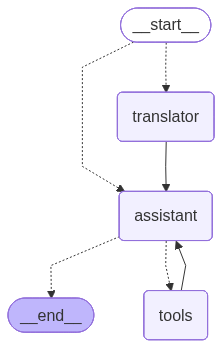

In [ ]:
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
def pretty_print_messages(response_state):
    messages = response_state.get("messages", [])
    for idx, msg in enumerate(messages):
        msg_type = msg.__class__.__name__
        print(f"\n[{idx}] {msg_type.upper()}")
        print("=" * 40)
        if msg_type == "ToolMessage":
            print(f"Tool Name: {msg.name}")
            print(f"Tool ID: {msg.tool_call_id}")
            print(f"Output:\n{msg.content}")
        elif msg_type == "AIMessage":
            if msg.tool_calls:
                print("Requesting Tool Execution:")
                for tool in msg.tool_calls:
                    print(f"  -> Tool: {tool['name']}")
                    print(f"  -> Arguments: {tool['args']}")
            if msg.content:
                print(f"Response:\n{msg.content}")
        else:
            print(f"Input:\n{msg.content}")

        print("-" * 40)

In [ ]:
response=await app.invoke({"messages":"Can I claim the right of private self-defense if I kill my attacker by strangling them after they are already beaten down and incapacitated?"})


NotImplementedError: StructuredTool does not support sync invocation.

In [ ]:
print(response["messages"][-1].text)

Under Nepali law, the partition of joint property is not a mandatory procedural prerequisite for a court to finalize a divorce decree. However, the law provides specific mechanisms for a wife to claim her share of property during or after the divorce process.

### LEGAL ANALYSIS
Based on the provided Supreme Court of Nepal precedents, the following principles apply:

*   **Independence of Divorce and Partition:** The court can grant a divorce decree without requiring the formal partition of all joint property as a condition precedent. Divorce and property partition are distinct legal actions.
*   **Wife's Right to Partition:** Under the *Muluki Civil Code, 2074*, a wife has the right to claim her share of the joint family property. If a husband and wife are divorcing, the wife may initiate a partition suit to secure her share of the ancestral or joint property.
*   **Protection of Property Rights:** The judiciary actively protects a spouse's right to property against malicious attempts

What are my legal rights as a loan guarantor if a bank or finance company auctions my collateral land to recover a debt without giving me prior notice

When a husband and wife file for divorce, does Nepali law require their joint property to be formally partitioned (divided) between them before the court can finalize the divorce decree?